In [1]:
path = '../Thesis_Data/'
import pandas as pd
df = pd.read_csv(path+'Final_Data/Final_Merged_Data.csv')
# df_sample = pd.read_csv('../Thesis_Data/Final_Data/sample_data.csv')

In [5]:
print(df.columns.tolist())
print(df.dtypes)

['Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt', 'parity', 'milk_kg', 'fat_p', 'protein_p', 'cells', 'NM', 'ECM', 'SCS', 'AFC', 'DIM', 'temperature_avg', 'temperature_max', 'temperature_min', 'humidity_avg', 'humidity_max', 'humidity_min', 'wind_speed_avg', 'wind_speed_max', 'wind_speed_min', 'THI_1_avg', 'THI_1_min', 'THI_1_max', 'THI_2_avg', 'THI_2_min', 'THI_2_max', 'WHI_avg', 'WHI_min', 'WHI_max', 'temperature_avg_lag1', 'temperature_avg_lag2', 'temperature_avg_lag3', 'humidity_avg_lag1', 'humidity_avg_lag2', 'humidity_avg_lag3', 'wind_speed_avg_lag1', 'wind_speed_avg_lag2', 'wind_speed_avg_lag3', 'THI_1_avg_lag1', 'THI_1_avg_lag2', 'THI_1_avg_lag3', 'THI_2_avg_lag1', 'THI_2_avg_lag2', 'THI_2_avg_lag3', 'WHI_avg_lag1', 'WHI_avg_lag2', 'WHI_avg_lag3', 'THI_1_Compose', 'THI_2_Compose']
Farm_Code                 int64
Animal_ID                object
dtb                      object
dtc                      object
dtt                      object
parity                    int64
milk_kg   

In [9]:
print(df['AFC'].value_counts().head(10))
print(df['AFC'].dtype)

AFC
1088 days 00:00:00    1914
1095 days 00:00:00    1831
1070 days 00:00:00    1811
1092 days 00:00:00    1802
1079 days 00:00:00    1779
1086 days 00:00:00    1779
1087 days 00:00:00    1749
1061 days 00:00:00    1737
1096 days 00:00:00    1728
1080 days 00:00:00    1727
Name: count, dtype: int64
object


In [32]:
# Fix AFC first
# df['AFC'] = pd.to_timedelta(df['AFC']).dt.days

targets = ['milk_kg', 'protein_p']

features = [
    # Animal info
    'AFC', 'DIM',
    # Weather current
    'temperature_avg', 'temperature_max', 'temperature_min',
    'humidity_avg', 'humidity_max', 'humidity_min',
    'wind_speed_avg', 'wind_speed_max', 'wind_speed_min',
    # Heat stress current
    'THI_1_avg', 'THI_1_min', 'THI_1_max',
    'THI_2_avg', 'THI_2_min', 'THI_2_max',
    'WHI_avg', 'WHI_min', 'WHI_max',
    # Lagged weather
    'temperature_avg_lag1', 'temperature_avg_lag2', 'temperature_avg_lag3',
    'humidity_avg_lag1', 'humidity_avg_lag2', 'humidity_avg_lag3',
    'wind_speed_avg_lag1', 'wind_speed_avg_lag2', 'wind_speed_avg_lag3',
    # Lagged heat stress
    'THI_1_avg_lag1', 'THI_1_avg_lag2', 'THI_1_avg_lag3',
    'THI_2_avg_lag1', 'THI_2_avg_lag2', 'THI_2_avg_lag3',
    'WHI_avg_lag1', 'WHI_avg_lag2', 'WHI_avg_lag3',
    # Composite stress
    'THI_1_Compose', 'THI_2_Compose',

    ## target lag
    'milk_kg_lag1',
       'milk_kg_lag2', 'protein_p_lag1', 'protein_p_lag2'
]

analysis_df = df[features + targets].dropna()
print(f"Analysis shape: {analysis_df.shape}")
print(f"Dropped rows (NaN): {len(df) - len(analysis_df):,}")

Analysis shape: (509401, 46)
Dropped rows (NaN): 162,254


PEARSON CORRELATION WITH TARGETS
   target              feature  pearson_r  p_value  significant
  milk_kg         milk_kg_lag1     0.6177 0.000000         True
  milk_kg                  DIM    -0.5415 0.000000         True
  milk_kg         milk_kg_lag2     0.4708 0.000000         True
  milk_kg       protein_p_lag1    -0.2446 0.000000         True
  milk_kg                  AFC     0.1643 0.000000         True
  milk_kg       protein_p_lag2    -0.1092 0.000000         True
  milk_kg        THI_1_Compose     0.0894 0.000000         True
  milk_kg        THI_2_Compose     0.0893 0.000000         True
  milk_kg      temperature_avg     0.0884 0.000000         True
  milk_kg      temperature_max     0.0879 0.000000         True
  milk_kg            THI_1_avg     0.0879 0.000000         True
  milk_kg            THI_2_avg     0.0879 0.000000         True
  milk_kg            THI_1_max     0.0860 0.000000         True
  milk_kg            THI_2_max     0.0860 0.000000         True
  milk_

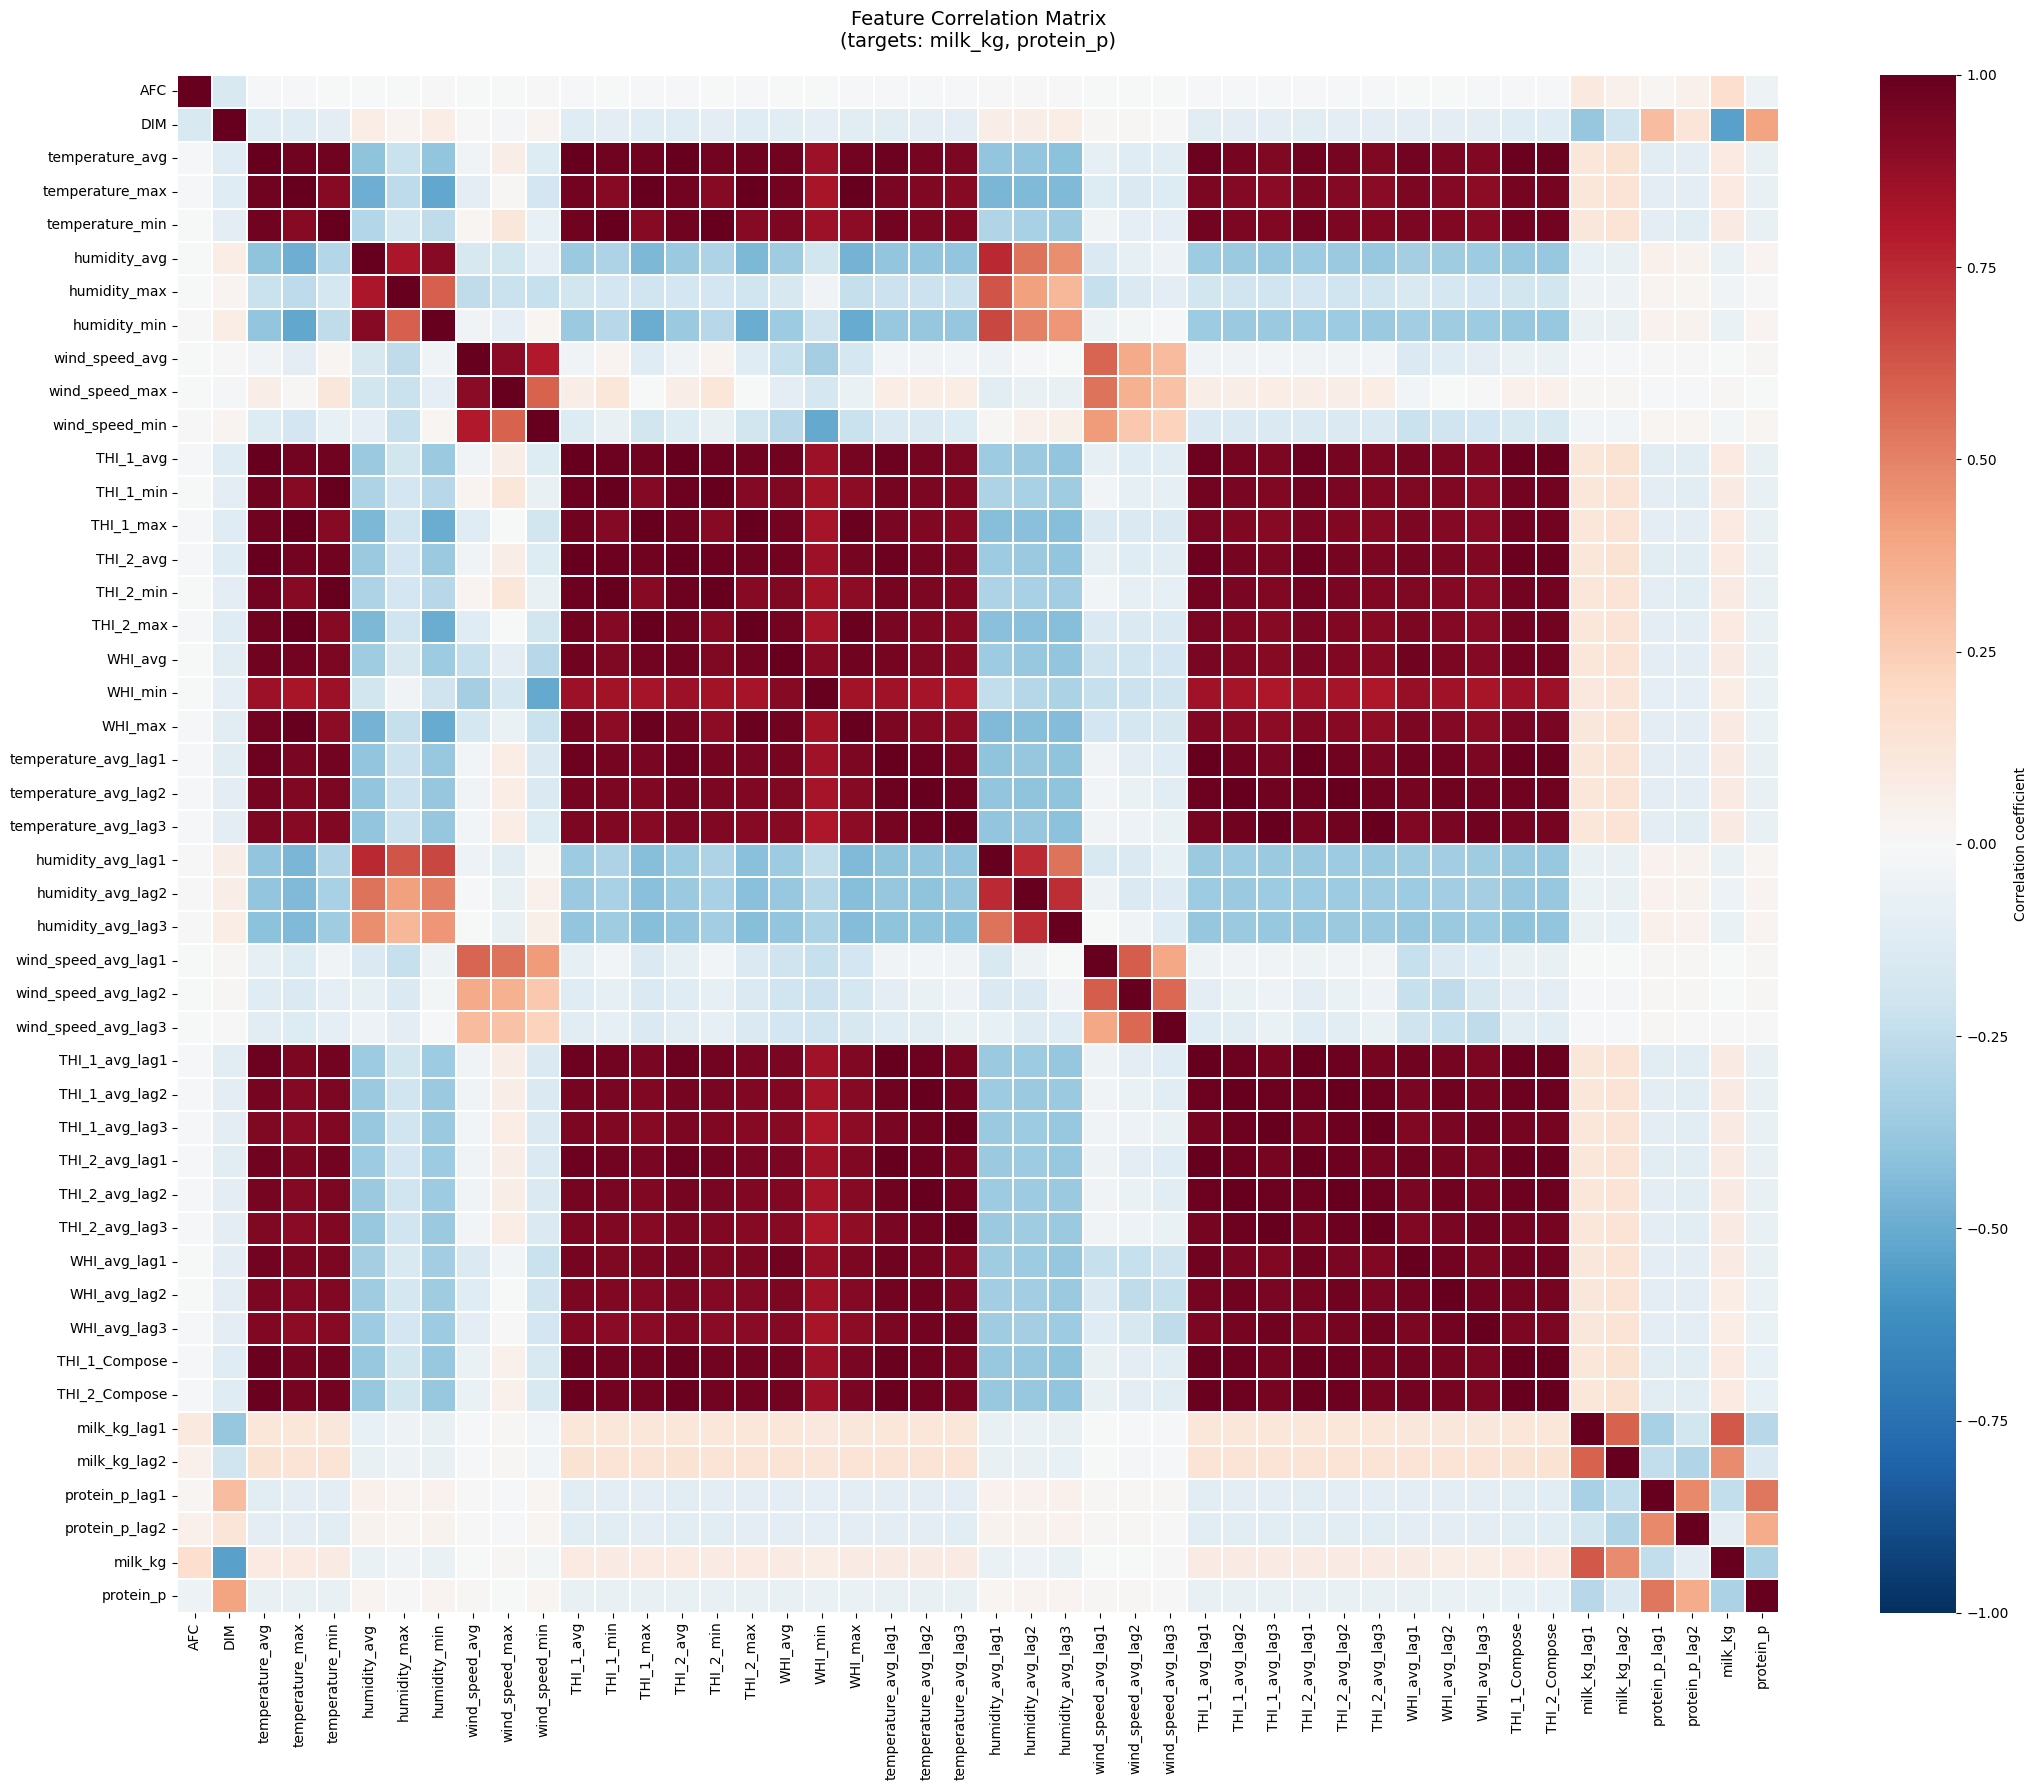

Heatmap saved ✅

MIXED EFFECTS MODEL — milk_kg (Farm as random effect)
            Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  milk_kg      
No. Observations:  509401   Method:              REML         
No. Groups:        314      Scale:               6.1321       
Min. group size:   4        Log-Likelihood:      -1185562.1979
Max. group size:   15838    Converged:           Yes          
Mean group size:   1622.3                                     
--------------------------------------------------------------
                 Coef.  Std.Err.    z     P>|z|  [0.025 0.975]
--------------------------------------------------------------
Intercept        15.969    4.000    3.993 0.000   8.130 23.807
DIM              -0.022    0.000 -479.580 0.000  -0.022 -0.022
AFC               0.002    0.000   82.961 0.000   0.002  0.002
THI_1_avg       -17.217    8.635   -1.994 0.046 -34.142 -0.292
THI_2_avg        17.112    8.549    2.002 0.045   0.356 33.8

In [33]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt

# ── 1. PEARSON CORRELATION + P-VALUES ─────────────────────────────────────────
print("=" * 60)
print("PEARSON CORRELATION WITH TARGETS")
print("=" * 60)

results = []
for target in targets:
    for feat in features:
        clean = analysis_df[[feat, target]].dropna()
        r, p = stats.pearsonr(clean[feat], clean[target])
        results.append({
            'target': target,
            'feature': feat,
            'pearson_r': round(r, 4),
            'p_value': round(p, 6),
            'significant': p < 0.05
        })

corr_df = pd.DataFrame(results).sort_values(['target', 'pearson_r'], 
                                              key=lambda x: x.abs() if x.name == 'pearson_r' else x,
                                              ascending=[True, False])
print(corr_df.to_string(index=False))
corr_df.to_csv('correlation_results.csv', index=False)


# ── 2. SPEARMAN CORRELATION (non-linear relationships) ────────────────────────
print("\n" + "=" * 60)
print("SPEARMAN CORRELATION WITH TARGETS")
print("=" * 60)

spearman_results = []
for target in targets:
    for feat in features:
        clean = analysis_df[[feat, target]].dropna()
        r, p = stats.spearmanr(clean[feat], clean[target])
        spearman_results.append({
            'target': target,
            'feature': feat,
            'spearman_r': round(r, 4),
            'p_value': round(p, 6),
            'significant': p < 0.05
        })

spearman_df = pd.DataFrame(spearman_results).sort_values(['target', 'spearman_r'],
                                                          key=lambda x: x.abs() if x.name == 'spearman_r' else x,
                                                          ascending=[True, False])
spearman_df.to_csv('spearman_results.csv', index=False)


# ── 3. CORRELATION HEATMAP ────────────────────────────────────────────────────
corr_matrix = analysis_df[features + targets].corr()

plt.figure(figsize=(22, 18))
mask = np.zeros_like(corr_matrix, dtype=bool)
sns.heatmap(corr_matrix, 
            mask=mask,
            cmap='RdBu_r', 
            center=0,
            vmin=-1, vmax=1,
            annot=False,
            linewidths=0.3,
            cbar_kws={'label': 'Correlation coefficient'})
plt.title('Feature Correlation Matrix\n(targets: milk_kg, protein_p)', 
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved ✅")


# ── 4. MIXED EFFECTS MODEL (hierarchy-aware) ──────────────────────────────────
print("\n" + "=" * 60)
print("MIXED EFFECTS MODEL — milk_kg (Farm as random effect)")
print("=" * 60)

# Use key features only to keep it tractable
key_features = ['DIM', 'AFC', 'THI_1_avg', 'THI_2_avg', 
                 'WHI_avg', 'humidity_avg', 'temperature_avg',
                 'THI_1_Compose', 'THI_2_Compose']

formula_milk = "milk_kg ~ " + " + ".join(key_features)
model_milk = smf.mixedlm(formula_milk, 
                          data=analysis_df.join(df['Farm_Code']), 
                          groups=df.loc[analysis_df.index, 'Farm_Code'])
result_milk = model_milk.fit(reml=True)
print(result_milk.summary())

print("\n" + "=" * 60)
print("MIXED EFFECTS MODEL — protein_p (Farm as random effect)")
print("=" * 60)

formula_protein = "protein_p ~ " + " + ".join(key_features)
model_protein = smf.mixedlm(formula_protein,
                              data=analysis_df.join(df['Farm_Code']),
                              groups=df.loc[analysis_df.index, 'Farm_Code'])
result_protein = model_protein.fit(reml=True)
print(result_protein.summary())

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = analysis_df[key_features].dropna()
vif_data = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data)

           feature           VIF
3        THI_2_avg  5.801315e+07
2        THI_1_avg  5.778078e+07
8    THI_2_Compose  5.058965e+07
7    THI_1_Compose  5.043224e+07
6  temperature_avg  4.688951e+02
5     humidity_avg  1.805662e+02
4          WHI_avg  4.992977e+01
1              AFC  4.027503e+01
0              DIM  3.748994e+00


In [ ]:
features_milk_kg = [
    'DIM',
    'THI_1_Compose',   # current stress composite
    'humidity_avg',    # humidity separate from THI (different biological mechanism)
]

features_protein_p = [
    'DIM',
    'WHI_avg',         # wind + humidity + temperature combined
    'THI_1_avg_lag1',  # lagged effect only (not current, to avoid THI/WHI overlap)
]

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for name, feats in [('milk_kg', features_milk_kg), ('protein_p', features_protein_p)]:
    X = analysis_df[feats].dropna()
    vif = pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)
    print(f"\n=== VIF for {name} features ===")
    print(vif.to_string(index=False))


=== VIF for milk_kg features ===
          feature         VIF
    THI_1_Compose 1591.988341
   THI_1_avg_lag1 1558.910392
              AFC   30.884371
humidity_avg_lag1   23.757780
              DIM    3.678585

=== VIF for protein_p features ===
          feature         VIF
        THI_1_avg 1104.592653
   THI_1_avg_lag1  960.468377
humidity_avg_lag1   41.785543
              AFC   37.325398
          WHI_avg   11.416031
              DIM    3.712806


In [18]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

features_milk_kg   = ['DIM', 'THI_1_Compose']
features_protein_p = ['DIM', 'WHI_avg', 'THI_1_avg_lag1']

for name, feats in [('milk_kg', features_milk_kg), ('protein_p', features_protein_p)]:
    X = analysis_df[feats].dropna()
    vif = pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)
    print(f"\n=== VIF for {name} features ===")
    print(vif.to_string(index=False))


=== VIF for milk_kg features ===
      feature      VIF
THI_1_Compose 3.429679
          DIM 3.429679

=== VIF for protein_p features ===
       feature      VIF
THI_1_avg_lag1 7.411587
           DIM 3.683766
       WHI_avg 3.540411


In [19]:
# Lagged target values — these will transform your predictions
df = df.sort_values(['Farm_Code', 'Animal_ID', 'dtt'])

df['milk_kg_lag1']   = df.groupby(['Farm_Code','Animal_ID'])['milk_kg'].shift(1)
df['milk_kg_lag2']   = df.groupby(['Farm_Code','Animal_ID'])['milk_kg'].shift(2)

df['protein_p_lag1'] = df.groupby(['Farm_Code','Animal_ID'])['protein_p'].shift(1)
df['protein_p_lag2'] = df.groupby(['Farm_Code','Animal_ID'])['protein_p'].shift(2)

In [20]:
for lag in ['milk_kg_lag1', 'milk_kg_lag2']:
    r, p = stats.pearsonr(
        df[['milk_kg', lag]].dropna()['milk_kg'],
        df[['milk_kg', lag]].dropna()[lag]
    )
    print(f"{lag} vs milk_kg: r={r:.4f}")

for lag in ['protein_p_lag1', 'protein_p_lag2']:
    r, p = stats.pearsonr(
        df[['protein_p', lag]].dropna()['protein_p'],
        df[['protein_p', lag]].dropna()[lag]
    )
    print(f"{lag} vs protein_p: r={r:.4f}")

milk_kg_lag1 vs milk_kg: r=0.6099
milk_kg_lag2 vs milk_kg: r=0.4708
protein_p_lag1 vs protein_p: r=0.5004
protein_p_lag2 vs protein_p: r=0.3734


In [25]:
selected_features = {
    'milk_kg':   ['DIM', 'THI_1_Compose', 'milk_kg_lag1', 'milk_kg_lag2'],
    'protein_p': ['DIM', 'WHI_avg', 'THI_1_avg_lag1', 'protein_p_lag1', 'protein_p_lag2']
}

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for name, feats in selected_features.items():
    target = name
    all_cols = feats + [target]
    X = df[all_cols].dropna()
    X_feats = X[feats]
    vif = pd.DataFrame({
        'feature': X_feats.columns,
        'VIF': [variance_inflation_factor(X_feats.values, i) 
                for i in range(X_feats.shape[1])]
    }).sort_values('VIF', ascending=False)
    print(f"\n=== VIF for {name} features ===")
    print(vif.to_string(index=False))


=== VIF for milk_kg features ===
      feature       VIF
THI_1_Compose 15.999703
 milk_kg_lag2 15.043282
 milk_kg_lag1 14.072188
          DIM  5.267354

=== VIF for protein_p features ===
       feature        VIF
protein_p_lag1 157.990521
THI_1_avg_lag1 156.179190
protein_p_lag2 145.293691
       WHI_avg  12.238884
           DIM   6.768041


In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

features_milk_kg   = ['DIM', 'THI_1_Compose', 'milk_kg_lag1']
features_protein_p = ['DIM', 'WHI_avg', 'protein_p_lag1']

for name, feats in [('milk_kg', features_milk_kg), ('protein_p', features_protein_p)]:
    X = df[feats].dropna()
    vif = pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)
    print(f"\n=== VIF for {name} features ===")
    print(vif.to_string(index=False))


=== VIF for milk_kg features ===
      feature       VIF
THI_1_Compose 13.843053
 milk_kg_lag1  8.627022
          DIM  4.383133

=== VIF for protein_p features ===
       feature      VIF
protein_p_lag1 6.708387
           DIM 5.192624
       WHI_avg 2.223517


In [28]:
features_milk_kg   = ['DIM', 'milk_kg_lag1']
features_protein_p = ['DIM', 'WHI_avg', 'protein_p_lag1']

for name, feats in [('milk_kg', features_milk_kg), ('protein_p', features_protein_p)]:
    X = df[feats].dropna()
    vif = pd.DataFrame({
        'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    }).sort_values('VIF', ascending=False)
    print(f"\n=== VIF for {name} features ===")
    print(vif.to_string(index=False))


=== VIF for milk_kg features ===
     feature      VIF
         DIM 2.633771
milk_kg_lag1 2.633771

=== VIF for protein_p features ===
       feature      VIF
protein_p_lag1 6.708387
           DIM 5.192624
       WHI_avg 2.223517


In [29]:
# For statistical analysis (MixedLM) — keep separate, VIF-clean
features_milk_kg_stats   = ['DIM', 'milk_kg_lag1']        # autoregressive
features_milk_kg_climate = ['DIM', 'THI_1_Compose']       # climate-only

# For ML/forecasting models — use full set, VIF irrelevant
features_milk_kg_ml = ['DIM', 'milk_kg_lag1', 'THI_1_Compose']
features_protein_p_ml = ['DIM', 'protein_p_lag1', 'WHI_avg', 'THI_1_avg_lag1']

In [30]:
import json

selected_features = {
    # For statistical interpretation (VIF-clean)
    'milk_kg_stats':    ['DIM', 'milk_kg_lag1'],
    'milk_kg_climate':  ['DIM', 'THI_1_Compose'],
    # For ML forecasting models
    'milk_kg_ml':       ['DIM', 'milk_kg_lag1', 'THI_1_Compose'],
    'protein_p_stats':  ['DIM', 'WHI_avg', 'protein_p_lag1'],
    'protein_p_ml':     ['DIM', 'protein_p_lag1', 'WHI_avg', 'THI_1_avg_lag1'],
}

with open('selected_features.json', 'w') as f:
    json.dump(selected_features, f, indent=2)

print(json.dumps(selected_features, indent=2))

{
  "milk_kg_stats": [
    "DIM",
    "milk_kg_lag1"
  ],
  "milk_kg_climate": [
    "DIM",
    "THI_1_Compose"
  ],
  "milk_kg_ml": [
    "DIM",
    "milk_kg_lag1",
    "THI_1_Compose"
  ],
  "protein_p_stats": [
    "DIM",
    "WHI_avg",
    "protein_p_lag1"
  ],
  "protein_p_ml": [
    "DIM",
    "protein_p_lag1",
    "WHI_avg",
    "THI_1_avg_lag1"
  ]
}


In [31]:
df.columns

Index(['Farm_Code', 'Animal_ID', 'dtb', 'dtc', 'dtt', 'parity', 'milk_kg',
       'fat_p', 'protein_p', 'cells', 'NM', 'ECM', 'SCS', 'AFC', 'DIM',
       'temperature_avg', 'temperature_max', 'temperature_min', 'humidity_avg',
       'humidity_max', 'humidity_min', 'wind_speed_avg', 'wind_speed_max',
       'wind_speed_min', 'THI_1_avg', 'THI_1_min', 'THI_1_max', 'THI_2_avg',
       'THI_2_min', 'THI_2_max', 'WHI_avg', 'WHI_min', 'WHI_max',
       'temperature_avg_lag1', 'temperature_avg_lag2', 'temperature_avg_lag3',
       'humidity_avg_lag1', 'humidity_avg_lag2', 'humidity_avg_lag3',
       'wind_speed_avg_lag1', 'wind_speed_avg_lag2', 'wind_speed_avg_lag3',
       'THI_1_avg_lag1', 'THI_1_avg_lag2', 'THI_1_avg_lag3', 'THI_2_avg_lag1',
       'THI_2_avg_lag2', 'THI_2_avg_lag3', 'WHI_avg_lag1', 'WHI_avg_lag2',
       'WHI_avg_lag3', 'THI_1_Compose', 'THI_2_Compose', 'milk_kg_lag1',
       'milk_kg_lag2', 'protein_p_lag1', 'protein_p_lag2'],
      dtype='object')